In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [ ]:
DATA_PATH = "../data/raw/divar.csv"
df = pd.read_csv(DATA_PATH)

C:\Users\IRANA COMPUTER\AppData\Local\Temp\ipykernel_21612\363932149.py:2: DtypeWarning: Columns (11,27,29,53) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


We start by selecting features that are important for user preferences, such as price, location and number of rooms.
we check different combinations to choose the best one.

In [4]:
features = [
    "price_value",
    "location_latitude",
    "location_longitude",
    "rooms_count",
    "building_size",
    "rent_value",
    "credit_value" 
]


In [5]:
df_cluster = df[features].copy()

In [6]:
df_cluster['rooms_count'].value_counts()

rooms_count
دو              404050
یک              192083
سه              138633
بدون اتاق        75898
چهار             21371
پنج یا بیشتر     13864
Name: count, dtype: int64

In [7]:
rooms_mapping = {
    "بدون اتاق": 0,
    "یک": 1,
    "دو": 2,
    "سه": 3,
    "چهار": 4,
    "پنج یا بیشتر": 5
}
df_cluster["rooms_count"] = df_cluster["rooms_count"] .map(rooms_mapping)

In [8]:
df_cluster.isna().sum()/df_cluster.shape[0]* 100

price_value           43.1654
location_latitude     34.4392
location_longitude    34.4392
rooms_count           15.4101
building_size          1.9606
rent_value            64.8678
credit_value          64.7905
dtype: float64

we use credit and rent values + price value to consider both sell and rent/credit ads

In [9]:
df_cluster["full_credit"] = df_cluster["rent_value"] / 30000 * 1000000 + df_cluster["credit_value"]

In [10]:
df_cluster["final_price"] = (
    df_cluster["price_value"]
    .fillna(df_cluster["full_credit"])
)

In [11]:
df_cluster.isna().sum()/df_cluster.shape[0]* 100

price_value           43.1654
location_latitude     34.4392
location_longitude    34.4392
rooms_count           15.4101
building_size          1.9606
rent_value            64.8678
credit_value          64.7905
full_credit           64.8808
final_price            8.0462
dtype: float64

In [12]:
import geopandas as gpd

In [13]:
iran = gpd.read_file("../data/maps/Iran_provinces.geojson")
iran_polygon = iran.union_all()

location_df = df_cluster[
    df_cluster["location_latitude"].notna() &
    df_cluster["location_longitude"].notna()
].copy()

location_gdf = gpd.GeoDataFrame(
    location_df,
    geometry=gpd.points_from_xy(
        location_df["location_longitude"],
        location_df["location_latitude"]
    ),
    crs="EPSG:4326",
)

iran_gdf = gpd.GeoDataFrame(
    geometry=[iran_polygon],
    crs="EPSG:4326"
)

inside = gpd.sjoin(
    location_gdf,
    iran_gdf,
    predicate="intersects",
    how="inner"
)

inside_index = inside.index

df_cluster = df_cluster.loc[inside_index].copy()

df_cluster.shape

(653849, 9)

In [14]:
df_cluster.shape

(653849, 9)

In [15]:
df_cluster.describe()

,price_value,location_latitude,location_longitude,rooms_count,building_size,rent_value,credit_value,full_credit,final_price
count,3.712040e+05,653849.000000,653849.000000,557841.000000,6.427910e+05,2.341910e+05,2.343280e+05,2.341770e+05,6.053810e+05
mean,1.824974e+10,34.996265,51.627028,1.841254,3.476202e+03,2.924772e+10,4.004314e+10,1.015048e+12,4.038371e+11
std,6.223542e+11,2.356555,3.158360,0.977281,1.189095e+05,2.630203e+12,3.997898e+12,8.991839e+13,5.592919e+13
min,0.000000e+00,25.135723,44.147400,0.000000,1.000000e+00,0.000000e+00,0.000000e+00,3.433333e+01,0.000000e+00
25%,1.490000e+09,34.575069,50.677895,1.000000,7.400000e+01,1.111110e+05,1.000000e+08,2.900000e+08,5.333333e+08
50%,2.900000e+09,35.723587,51.345551,2.000000,1.000000e+02,5.000000e+06,2.500000e+08,5.000000e+08,1.550000e+09
75%,6.000000e+09,36.307362,51.802799,2.000000,1.600000e+02,1.200000e+07,5.000000e+08,9.700000e+08,3.900000e+09
max,1.000000e+14,39.681236,62.843330,5.000000,1.000000e+07,1.000000e+15,1.000000e+15,3.433333e+16,3.433333e+16


it seems there is some outliers in price value column and final value column (by comparing min values and max values)


Now, we create several different feature sets and compare them to find the best combination of features.

In [16]:
features_1 = [
    "price_value",
    "location_latitude",
    "location_longitude"
]
features_2 = [
    "price_value",
    "location_latitude",
    "location_longitude",
    "rooms_count",
    "building_size"

]
features_3 = [
    "final_price",
    "location_latitude",
    "location_longitude",
]


In [17]:
df_price_loc = df_cluster[features_1].copy()
df_price_loc_room_size = df_cluster[features_2].copy()
df_allprice_loc = df_cluster[features_3].copy()

We remove rows with missing values in the selected clustering features because KMeans is distance-based and imputed values may create artificial clusters.

In [18]:
df_price_loc = df_price_loc[
    (df_price_loc["price_value"].notna()) &
    (df_price_loc["price_value"] > 0) 
].copy()
lower = df_price_loc['price_value'].quantile(0.02)
upper = df_price_loc['price_value'].quantile(0.98)
df_price_loc = df_price_loc[df_price_loc['price_value'].between(lower, upper)].copy()

In [19]:
df_price_loc_room_size = df_price_loc_room_size[
    (df_price_loc_room_size["price_value"].notna()) &
    (df_price_loc_room_size["rooms_count"].notna()) &
    (df_price_loc_room_size["building_size"].notna()) &
    (df_price_loc_room_size["price_value"] > 0) &
    (df_price_loc_room_size["building_size"] > 0) &
    (df_price_loc_room_size["building_size"] < 1000) 
].copy()

lower = df_price_loc_room_size['price_value'].quantile(0.02)
upper = df_price_loc_room_size['price_value'].quantile(0.98)
df_price_loc_room_size = df_price_loc_room_size[df_price_loc_room_size['price_value'].between(lower, upper)].copy()
lower = df_price_loc_room_size['building_size'].quantile(0.02)
upper = df_price_loc_room_size['building_size'].quantile(1)
df_price_loc_room_size = df_price_loc_room_size[df_price_loc_room_size['building_size'].between(lower, upper)].copy()

In [20]:
df_allprice_loc = df_allprice_loc[
        (df_allprice_loc["final_price"].notna()) &
        (df_allprice_loc["final_price"] > 0) 
].copy()

lower = df_allprice_loc['final_price'].quantile(0.02)
upper = df_allprice_loc['final_price'].quantile(0.98)
df_allprice_loc = df_allprice_loc[df_allprice_loc['final_price'].between(lower, upper)].copy()

In [21]:
feature_sets = {
    "price_location": df_price_loc,
    "price_price_loc_room_size ": df_price_loc_room_size,
    "final_price_loc": df_allprice_loc
}

scaled_feature_sets = {}
scalers = {}

for name, df_features in feature_sets.items():
    scaler = StandardScaler()
    
    scaled_feature_sets[name] = scaler.fit_transform(df_features)
    scalers[name] = scaler

KMeans is a distance-based algorithm, so features are scaled before clustering.

In [22]:

from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

results = []
kmeans_models = {}
cluster_labels = {}

for name, X in scaled_feature_sets.items():
    kmeans = KMeans(
        n_clusters=10,
        random_state=42,
    )
    
    labels = kmeans.fit_predict(X)
    
    kmeans_models[name] = kmeans
    cluster_labels[name] = labels
    
    sample_size = min(10000, X.shape[0])
    sample_idx = np.random.RandomState(42).choice(
        X.shape[0],
        size=sample_size,
        replace=False
    )
    
    results.append({
        "feature_set": name,
        "inertia": kmeans.inertia_,
        "silhouette_score": silhouette_score(X[sample_idx], labels[sample_idx]),
        "calinski_harabasz_score": calinski_harabasz_score(X, labels),
        "davies_bouldin_score": davies_bouldin_score(X, labels)
    })

results_df = pd.DataFrame(results)
results_df

,feature_set,inertia,silhouette_score,calinski_harabasz_score,davies_bouldin_score
0,price_location,156170.233158,0.420288,230607.584158,0.828187
1,price_price_loc_room_size,424456.804299,0.333715,69497.704071,1.106740
2,final_price_loc,245849.236362,0.452302,391998.129789,0.869849


Based on these scores, I choose the `final_price_loc` feature set. It has the highest silhouette score, so the clusters are more separated. It also has the highest Calinski-Harabasz score, which shows better cluster quality. Its Davies-Bouldin score is a little higher than `price_location`, but it is still acceptable. 


Now, we also look at it visually(scatter plot) to help make a better decision.


In [23]:
centers_dfs = {}

for name, kmeans in kmeans_models.items():
    centers_original = scalers[name].inverse_transform(
        kmeans.cluster_centers_
    )
    
    centers_df = pd.DataFrame(
        centers_original,
        columns=feature_sets[name].columns
    )
    
    centers_df["cluster"] = range(10)
    centers_df["feature_set"] = name
    
    centers_dfs[name] = centers_df


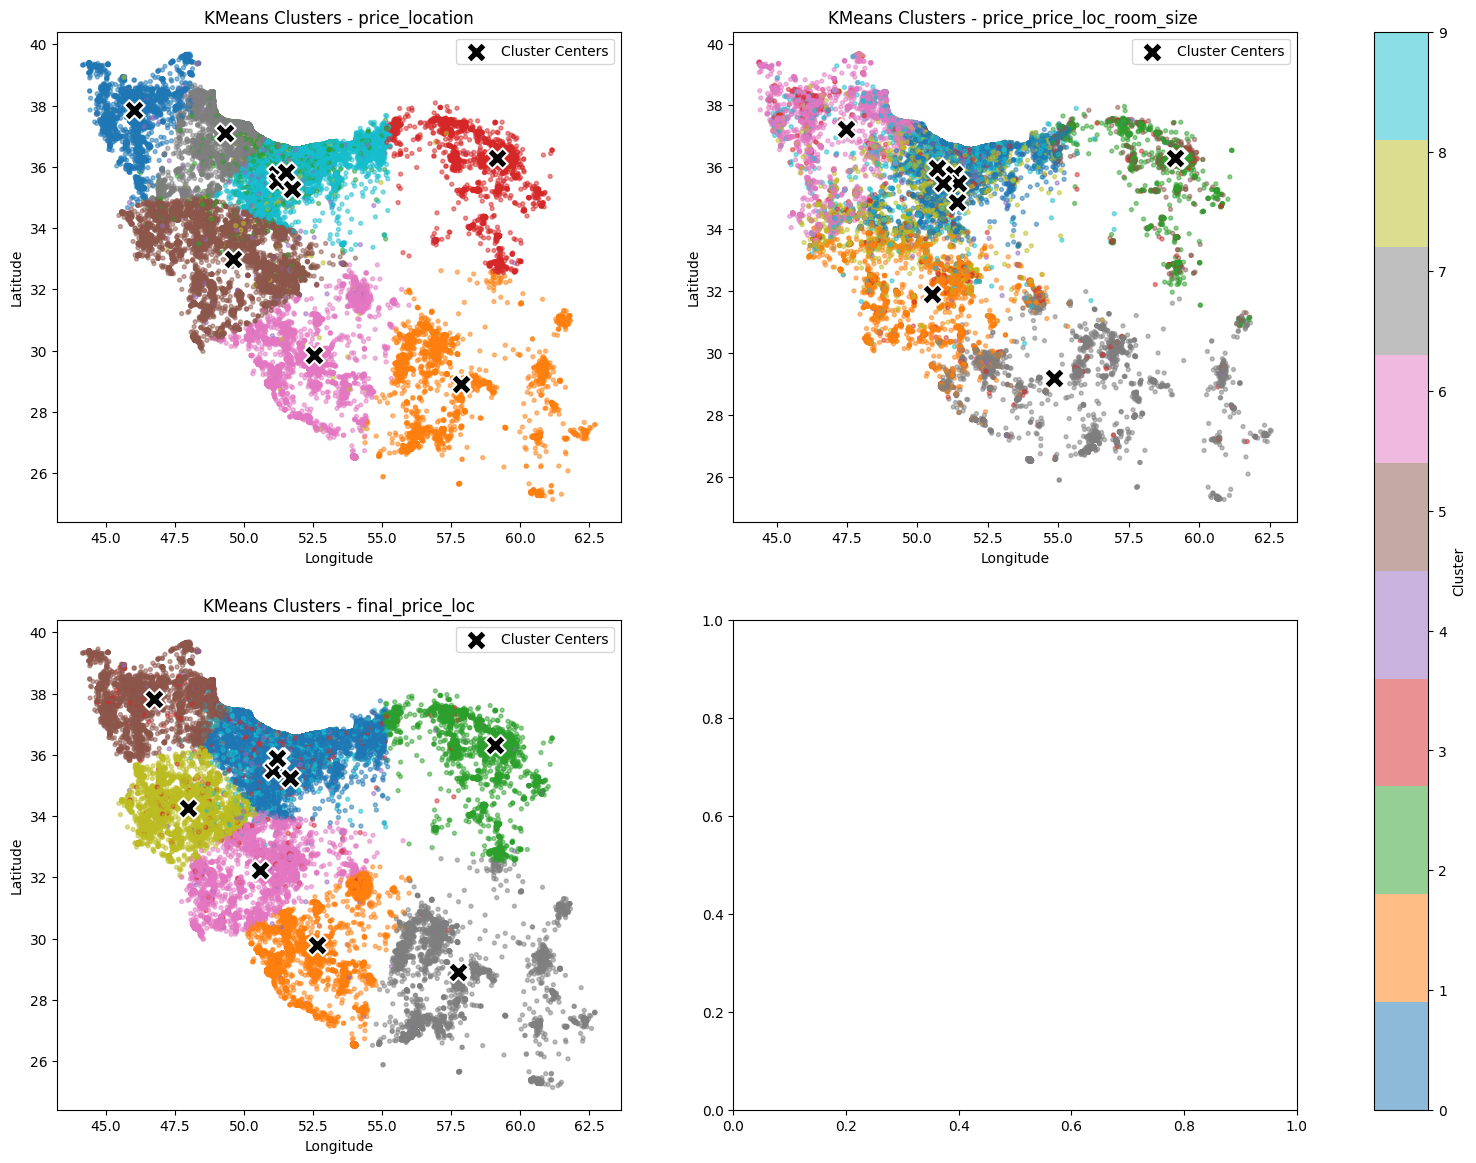

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes = axes.ravel()

for ax, name in zip(axes, feature_sets.keys()):
    
    df_plot = feature_sets[name].copy()
    df_plot["cluster"] = cluster_labels[name]
    centers = centers_dfs[name]
    
    scatter = ax.scatter(
        df_plot["location_longitude"],
        df_plot["location_latitude"],
        c=df_plot["cluster"],
        cmap="tab10",
        vmin=0,
        vmax=9,
        s=8,
        alpha=0.5
    )
    
    ax.scatter(
        centers["location_longitude"],
        centers["location_latitude"],
        c="black",
        marker="X",
        s=220,
        edgecolors="white",
        linewidths=1.5,
        label="Cluster Centers"
    )
    
    ax.set_title(f"KMeans Clusters - {name}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend()

fig.colorbar(scatter, ax=axes, label="Cluster")

plt.show()

Based on the scores and the visual results, I choose the (final_price + location). This feature set had better scores, especially a higher silhouette score and a higher Calinski-Harabasz score. In the visualization, the clusters are also clearer and more meaningful.

Also, this plot includes both sale ads and rent ads. Because of this, it gives a more complete view of the real estate data. So, I think this feature set is the better choice.


Latitude and longitude convertion to UTM

In [25]:
import utm

In [26]:
df_final_price_loc_plot = df_allprice_loc.copy()
df_final_price_loc_plot["cluster"] = cluster_labels["final_price_loc"]

utm_x, utm_y, zone_number, zone_letter = utm.from_latlon(
    df_final_price_loc_plot["location_latitude"].values,
    df_final_price_loc_plot["location_longitude"].values,
    force_zone_number=39
)

df_final_price_loc_plot["utm_x"] = utm_x
df_final_price_loc_plot["utm_y"] = utm_y
df_final_price_loc_plot["utm_zone_number"] = 39
df_final_price_loc_plot["utm_zone_letter"] = zone_letter


df_final_price_loc_plot.head()

,final_price,location_latitude,location_longitude,cluster,utm_x,utm_y,utm_zone_number,utm_zone_letter
2,1.616667e+09,35.703865,51.373459,0,533784.424602,3.951168e+06,39,S
7,8.700000e+09,35.729832,51.505466,9,545711.558185,3.954101e+06,39,S
8,6.500000e+08,35.712364,50.794781,0,481437.130969,3.952066e+06,39,S
10,2.600000e+09,35.778664,51.757549,0,568467.028494,3.959664e+06,39,S
11,1.200000e+09,35.733952,51.380608,0,534418.187237,3.954507e+06,39,S


In [27]:
df_final_price_loc_plot.shape

(580233, 8)

In [28]:
final_price_loc_centers = centers_dfs["final_price_loc"].copy()

center_utm_x, center_utm_y, center_zone_number, center_zone_letter = utm.from_latlon(
    final_price_loc_centers["location_latitude"].values,
    final_price_loc_centers["location_longitude"].values,
    force_zone_number=39
)

final_price_loc_centers["utm_x"] = center_utm_x
final_price_loc_centers["utm_y"] = center_utm_y
final_price_loc_centers["utm_zone_number"] = 39
final_price_loc_centers["utm_zone_letter"] = center_zone_letter

final_price_loc_centers.head()

,final_price,location_latitude,location_longitude,cluster,feature_set,utm_x,utm_y,utm_zone_number,utm_zone_letter
0,1.277724e+09,35.896086,51.274776,0,final_price_loc,5.247973e+05,3.972458e+06,39,S
1,2.356868e+09,29.805772,52.635203,1,final_price_loc,6.580287e+05,3.298385e+06,39,S
2,2.049329e+09,36.311600,59.076739,2,final_price_loc,1.225782e+06,4.048920e+06,39,S
3,1.233146e+10,35.498203,51.043708,3,final_price_loc,5.039641e+05,3.928295e+06,39,S
4,2.302403e+10,35.256707,51.650320,4,final_price_loc,5.591572e+05,3.901705e+06,39,S


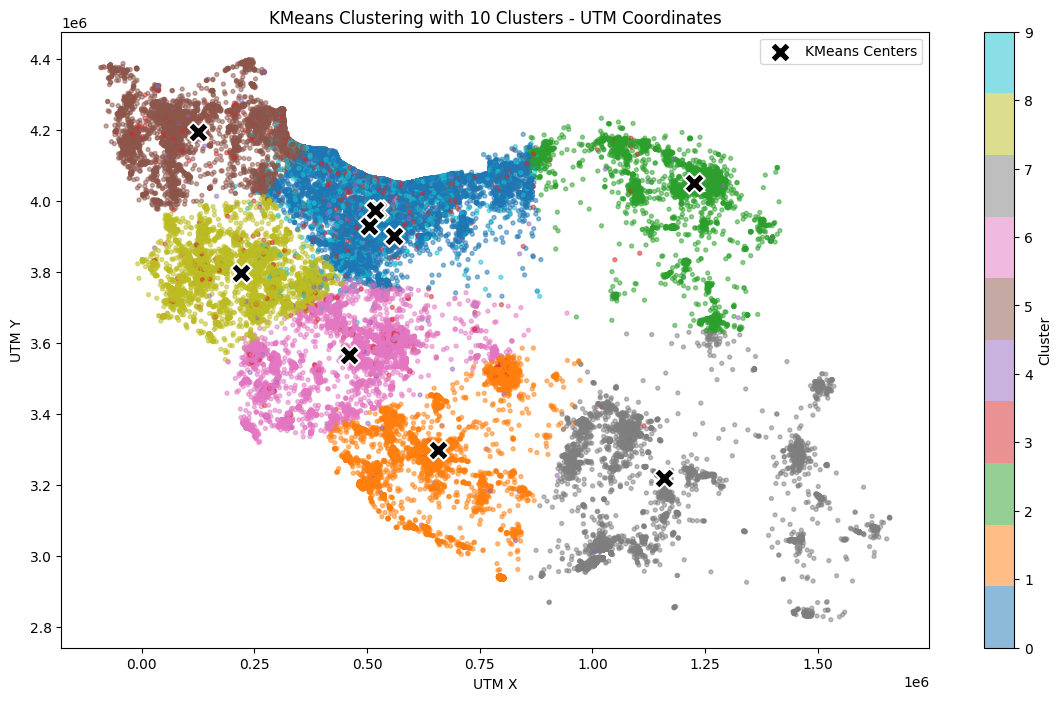

In [29]:
plt.figure(figsize=(14, 8))

scatter = plt.scatter(
    df_final_price_loc_plot["utm_x"],
    df_final_price_loc_plot["utm_y"],
    c=df_final_price_loc_plot["cluster"],
    cmap="tab10",
    vmin=0,
    vmax=9,
    s=8,
    alpha=0.5
)

plt.scatter(
    final_price_loc_centers["utm_x"],
    final_price_loc_centers["utm_y"],
    c="black",
    marker="X",
    s=220,
    edgecolors="white",
    linewidths=1.5,
    label="KMeans Centers"
)

plt.title("KMeans Clustering with 10 Clusters - UTM Coordinates")
plt.xlabel("UTM X")
plt.ylabel("UTM Y")

plt.colorbar(scatter, label="Cluster")
plt.legend()
plt.show()

### Part 2


In [37]:
from sklearn.cluster import DBSCAN

In [31]:
final_feature_set_name = "final_price_loc"

X_final = scaled_feature_sets[final_feature_set_name]

In [32]:
res = []
for k in range(1, 21) :
    kmeans = KMeans(k, random_state=42)
    kmeans.fit(X_final)
    res.append(kmeans.inertia_)



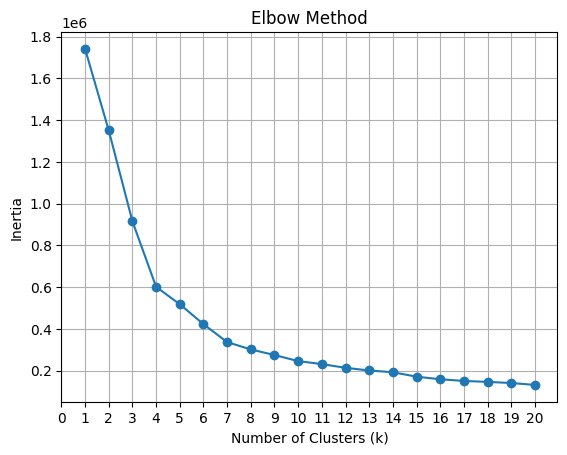

In [33]:
plt.plot(range(1,21), res, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(range(0, 21))
plt.grid(True)
plt.show()

In [34]:
X_final.shape

(580233, 3)

In [35]:
sample_size = min(10000, X_final.shape[0])
sample_idx = np.random.RandomState(42).choice(
    X_final.shape[0],
    size=sample_size,
    replace=False
)
res = []
for k in range(2, 21) :
    kmeans = KMeans(k, random_state=42)
    kmeans.fit(X_final)
    res.append(silhouette_score(X_final[sample_idx], kmeans.labels_[sample_idx]))



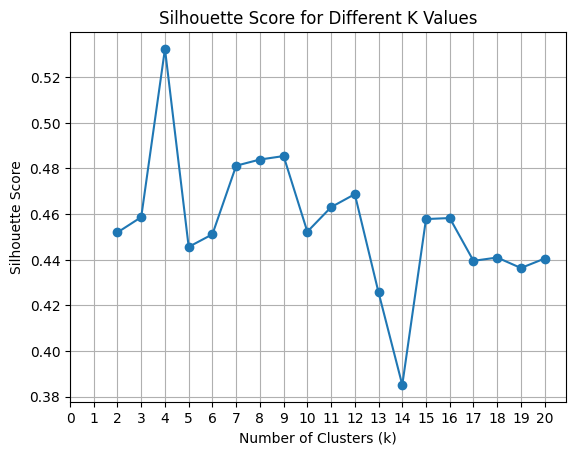

In [36]:
plt.plot(range(2,21), res, marker='o')
plt.title("Silhouette Score for Different K Values")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(range(0, 21))
plt.grid(True)

plt.show()

The elbow plot shows two possible elbow points around k = 4 and k = 7.  
To make a more reliable decision, we also compare the silhouette scores. Since k = 4 has a higher silhouette score, it shows a better cluster separation.  
However, from 4 to 7 clusters, there is still a clear decrease.   
Also, in my opinion, dividing all real estate data in Iran into only 4 groups is not logical because Iran has a large geographical area. Therefore, 7 clusters seem to be a better choice.
